In [21]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import pearsonr

sys.path.insert(0, str(Path('..').resolve().parent))
from config.preprocess_config import T
from evaluate.micro_cond import adherence_table

Path('../../figures').mkdir(parents=True, exist_ok=True)


In [22]:
# Plot config
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_GEN_CA = '#A8ECFF'
C_GEN_CAFILM = '#38CFEA'
C_REAL = 'tab:blue'
C_NORMAL = 'tab:red'
MODEL_COLORS = {'ca': C_GEN_CA, 'ca-film': C_GEN_CAFILM}
MODEL_LABELS = {'ca': 'CA', 'ca-film': 'CA-Film'}

print("Plot config defined.")

Plot config defined.


In [23]:
"""
Get generated data.
"""

MODEL_DIRS = {
    'ca': Path('../../data/generated/ca'),
    'ca-film': Path('../../data/generated/ca-film'),
}

ALL_FILES = [
    't-10r30i5v20.json',
    't-10r30i8v35.json',
    't-10r50i5v20.json',
    't-10r80i5v20.json',
    't-10r80i8v35.json',
    't0r80i5v20.json',
    't10r30i5v20.json',
    't10r30i8v35.json',
    't10r50i5v20.json',
    't10r80i5v20.json',
    't10r80i8v35.json',
]

gen_data = {}
for model, base_dir in MODEL_DIRS.items():
    gen_data[model] = {}
    for filename in ALL_FILES:
        with open(base_dir / filename) as f:
            payload = json.load(f)
        samples = np.array(payload['samples'], dtype=np.float64)
        t_tgt = payload['conditions']['trend']
        r_tgt = payload['conditions']['realized_vol']
        mean_w = t_tgt / (100.0 * T)
        var_w  = (r_tgt / (100.0 ** 2) - T * mean_w ** 2) / (T - 1)
        std_w  = np.sqrt(np.maximum(var_w, 1e-12))
        samples = samples * std_w + mean_w  # back to original log-return scale

        gen_data[model][filename] = {
            'n_samples':      samples.shape[0],
            'trend_target':   t_tgt,
            'trend_achieved': np.sum(samples * 100, axis=1),
            'rv_target':      r_tgt,
            'rv_achieved':    np.sum((samples * 100) ** 2, axis=1),
        }

print("Generated data loaded.")


Generated data loaded.


In [24]:
"""
3.1 - Trend adherence.
"""

print(f"{'=' * 25} Trend Adherence {'=' * 26}\n")
trend_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('trend', model, gen_data, ALL_FILES)
    trend_pts[model] = (targets, mean_achieved)
    print()


========================= Trend Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r30i5v20.json         -10.00    -10.0892      3.9444      0.0892
t-10r30i8v35.json         -10.00    -10.0562      3.5223      0.0562
t-10r50i5v20.json         -10.00    -10.0978      4.1511      0.0978
t-10r80i5v20.json         -10.00    -10.0686      5.2716      0.0686
t-10r80i8v35.json         -10.00    -10.1462      4.8194      0.1462
t0r80i5v20.json             0.00     -0.1256      5.3348      0.1256
t10r30i5v20.json           10.00      9.9980      2.9809      0.0020
t10r30i8v35.json           10.00      9.8835      3.8408      0.1165
t10r50i5v20.json           10.00     10.0216      3.5011      0.0216
t10r80i5v20.json           10.00      9.7671      5.8260      0.2329
t10r80i8v35.json           10.00      9.8832      6.7763      0.1168
─────────────────────────────────

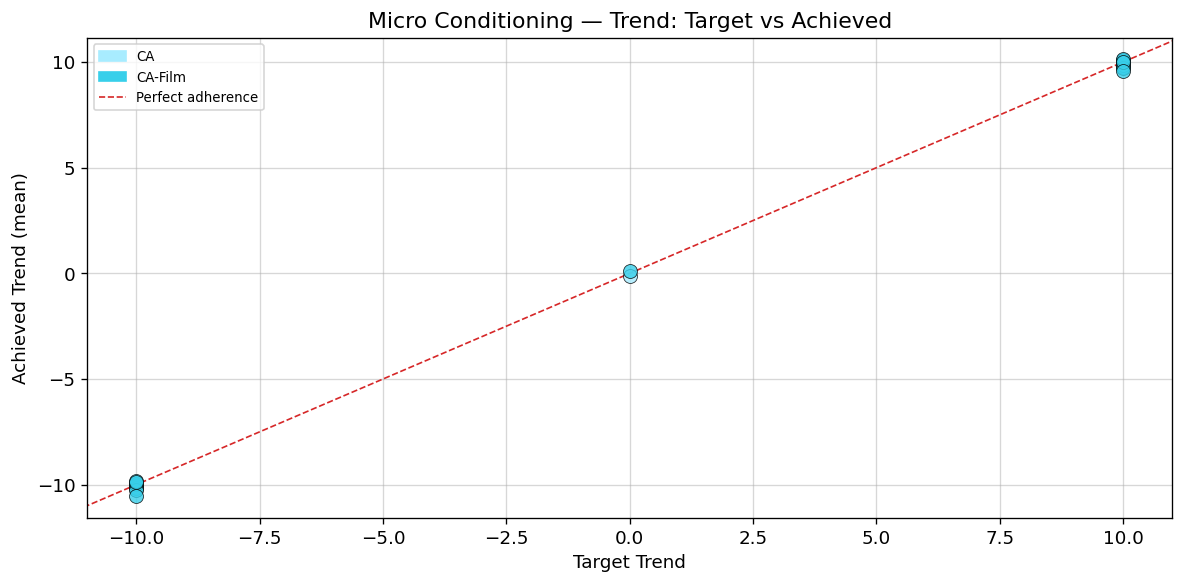

In [25]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in trend_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Trend')
ax.set_ylim(ylim)
ax.set_ylabel('Achieved Trend (mean)')
ax.set_title('Micro Conditioning — Trend: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_trend.png')
plt.show()


In [26]:
"""
3.2 - Realized volatility adherence.
"""

print(f"{'=' * 25} Realized Vol Adherence {'=' * 26}\n")
rv_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('rv', model, gen_data, ALL_FILES)
    rv_pts[model] = (targets, mean_achieved)
    print()


========================= Realized Vol Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r30i5v20.json          30.00     39.7298    131.0345      9.7298
t-10r30i8v35.json          30.00     37.9422    123.2955      7.9422
t-10r50i5v20.json          50.00     62.7278    212.2121     12.7278
t-10r80i5v20.json          80.00     99.8499    298.1776     19.8499
t-10r80i8v35.json          80.00     92.9397    153.2189     12.9397
t0r80i5v20.json            80.00    100.9709    349.6462     20.9709
t10r30i5v20.json           30.00     36.1251    103.2269      6.1251
t10r30i8v35.json           30.00     38.8228    162.4071      8.8228
t10r50i5v20.json           50.00     59.5708    145.2615      9.5708
t10r80i5v20.json           80.00     92.9623    151.3004     12.9623
t10r80i8v35.json           80.00    108.3813    560.8427     28.3813
──────────────────────────

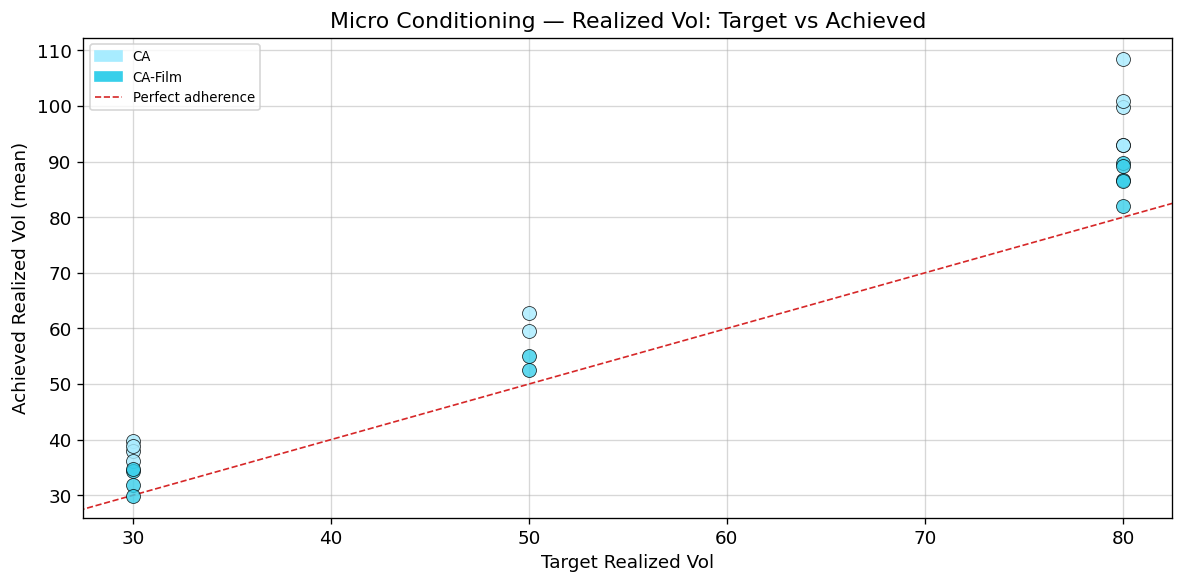

In [27]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in rv_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Realized Vol')
ax.set_ylim(ylim)
ax.set_ylabel('Achieved Realized Vol (mean)')
ax.set_title('Micro Conditioning — Realized Vol: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_rv.png')
plt.show()

